# **Jamboree Education Linear Regression Case Study:**

**About Jamboree:**

Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort. They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

**Business Problem:**

Understand what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.


**Dataset (Column Profiling):**

Serial No. (Unique row ID)

GRE Scores (out of 340)

TOEFL Scores (out of 120)

University Rating (out of 5)

Statement of Purpose and Letter of Recommendation Strength (out of 5)

Undergraduate GPA (out of 10)

Research Experience (either 0 or 1)

Chance of Admit (ranging from 0 to 1)

**Concepts Used:**

Exploratory Data Analysis

Linear Regression

# **Part A: Data Analysis:**

In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [2]:
# Read the Aerofit dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/Jamboree_Admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
# Print the last 5 rows
df.tail()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73
499,500,327,113,4,4.5,4.5,9.04,0,0.84


In [4]:
# Print the shape of the dataframe
df.shape

(500, 9)

### **The dataset has 500 records with 9 features.**

In [5]:
# Drop the Serial No. feature since it is redundant
df = df.drop("Serial No.", axis = 1)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [7]:
# Data type of the attributes of the dataframe
df.dtypes

,0
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance of Admit,float64


In [8]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [9]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

# **Part B: Data Pre-Processing:**

In [10]:
# Rename the columns for better modelling
df = df.rename(columns = {'GRE Score': 'GREScore', 'TOEFL Score': 'TOEFLScore', 'University Rating': 'UniversityRating',
                 'LOR ': 'LOR', 'Research': 'ResearchExperience', 'Chance of Admit ': 'ChanceOfAdmit'})

In [11]:
df.keys()

Index(['GREScore', 'TOEFLScore', 'UniversityRating', 'SOP', 'LOR', 'CGPA',
       'ResearchExperience', 'ChanceOfAdmit'],
      dtype='object')

In [12]:
df.nunique()

,0
GREScore,49
TOEFLScore,29
UniversityRating,5
SOP,9
LOR,9
CGPA,184
ResearchExperience,2
ChanceOfAdmit,61


In [13]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [14]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
GREScore,0,0.0
TOEFLScore,0,0.0
UniversityRating,0,0.0
SOP,0,0.0
LOR,0,0.0
CGPA,0,0.0
ResearchExperience,0,0.0
ChanceOfAdmit,0,0.0


# **The dataset is clean with no duplicates and no missing values!**

In [15]:
df['GREScore'].value_counts()

,count
GREScore,
312,24
324,23
316,18
322,17
327,17
321,17
311,16
320,16
314,16


In [16]:
df['TOEFLScore'].value_counts()

,count
TOEFLScore,
110,44
105,37
104,29
106,28
107,28
112,28
103,25
100,24
102,24


In [17]:
df['UniversityRating'].value_counts()

,count
UniversityRating,
3,162
2,126
4,105
5,73
1,34


In [18]:
df['SOP'].value_counts()

,count
SOP,
4.0,89
3.5,88
3.0,80
2.5,64
4.5,63
2.0,43
5.0,42
1.5,25
1.0,6


In [19]:
df['LOR'].value_counts()

,count
LOR,
3.0,99
4.0,94
3.5,86
4.5,63
2.5,50
5.0,50
2.0,46
1.5,11
1.0,1


In [20]:
df['CGPA'].value_counts()

,count
CGPA,
8.00,9
8.76,9
8.56,7
8.12,7
8.45,7
...,...
7.57,1
7.21,1
9.27,1


In [21]:
df['ResearchExperience'].value_counts()

,count
ResearchExperience,
1,280
0,220


In [22]:
df['ChanceOfAdmit'].value_counts()

,count
ChanceOfAdmit,
0.71,23
0.64,19
0.73,18
0.72,16
0.79,16
...,...
0.60,2
0.51,2
0.43,1


# **Part C: Exploratory Data Analysis:**

# **Part C1: Univariate Analysis:**

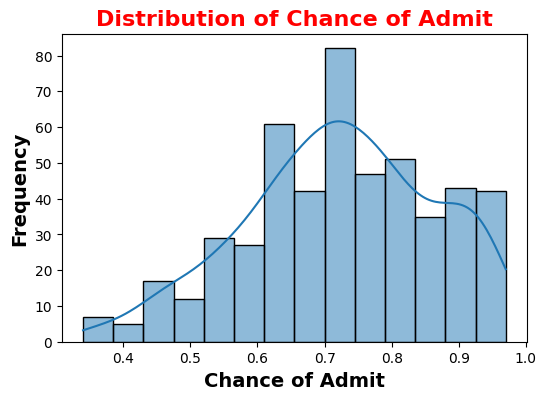

In [23]:
# Target variable distribution
plt.figure(figsize = (6,4))
sns.histplot(df['ChanceOfAdmit'], kde = True)
plt.title('Distribution of Chance of Admit', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel("Chance of Admit", fontsize = 14, fontweight = 'bold')
plt.ylabel("Frequency", fontsize = 14, fontweight = 'bold')
plt.show()

### **The target variable (Chance of Admit) is approximately normally distributed with a slight right skew, indicating most applicants have a moderate to high probability of admission, clustered around ~0.7.**

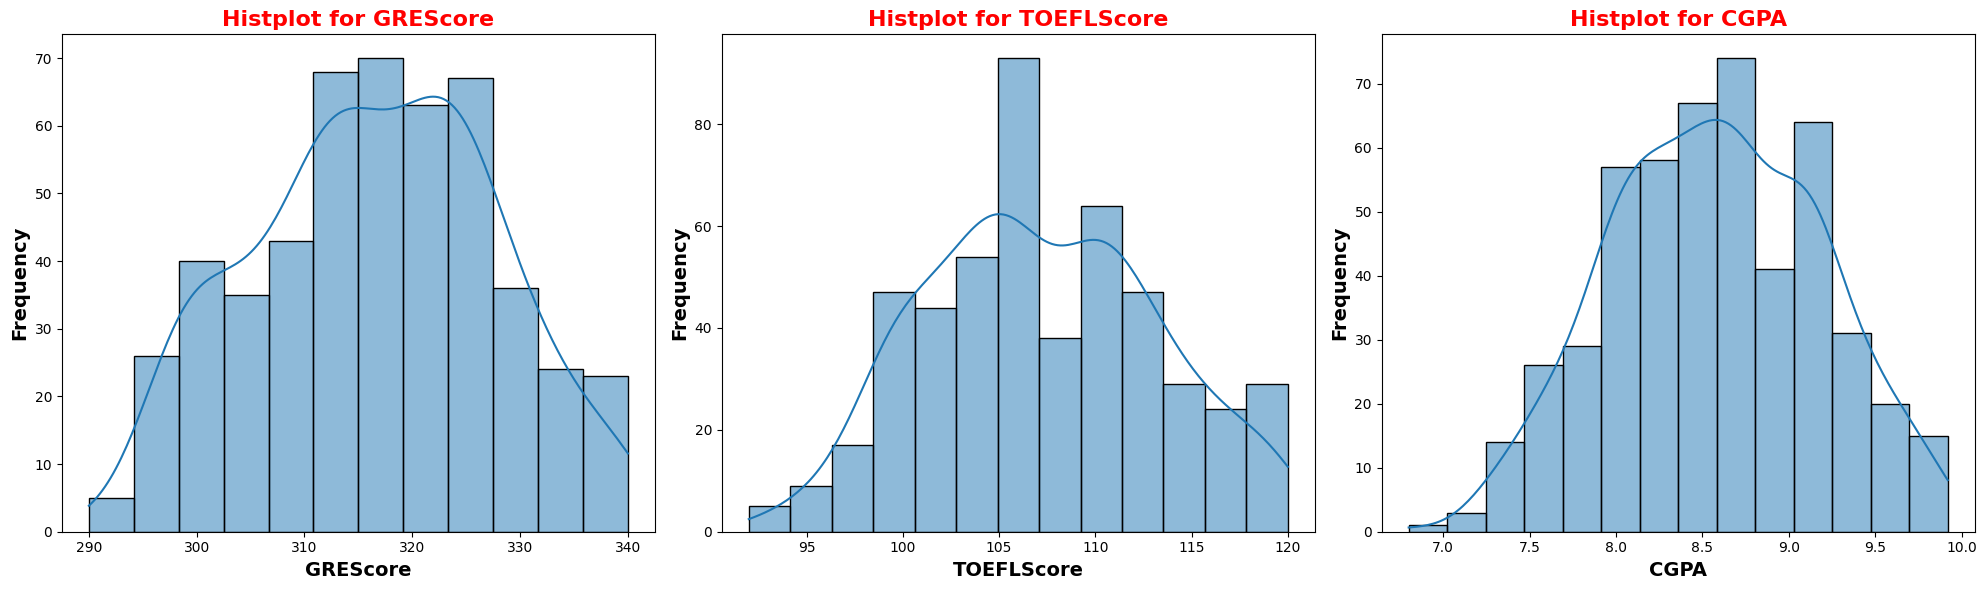

In [24]:
# Histplots for the GRE Score, TOEFL Score and CGPA
features = ['GREScore', 'TOEFLScore', 'CGPA']

fig, axes = plt.subplots(1, 3, figsize = (20, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(x = df[feature], kde = True, ax = ax)
    ax.set_title(f'Histplot for {feature}', fontsize = 16, fontweight = 'bold', color = 'red')
    ax.set_xlabel(feature, fontsize = 14, fontweight = 'bold')
    ax.set_ylabel('Frequency', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

### **GRE Score: GRE scores are approximately normally distributed, centered around 310-330, indicating most applicants have competitive GRE performance with few extremes.**

### **TOEFL Score: Similar to GRE scores, TOEFL scores show a near-normal distribution with a slight right skew, suggesting most applicants score between 100–110, reflecting generally strong English proficiency.**

### **CGPA: CGPA is slightly left-skewed with a strong concentration between 8.0–9.0, indicating the dataset is dominated by academically strong applicants.**

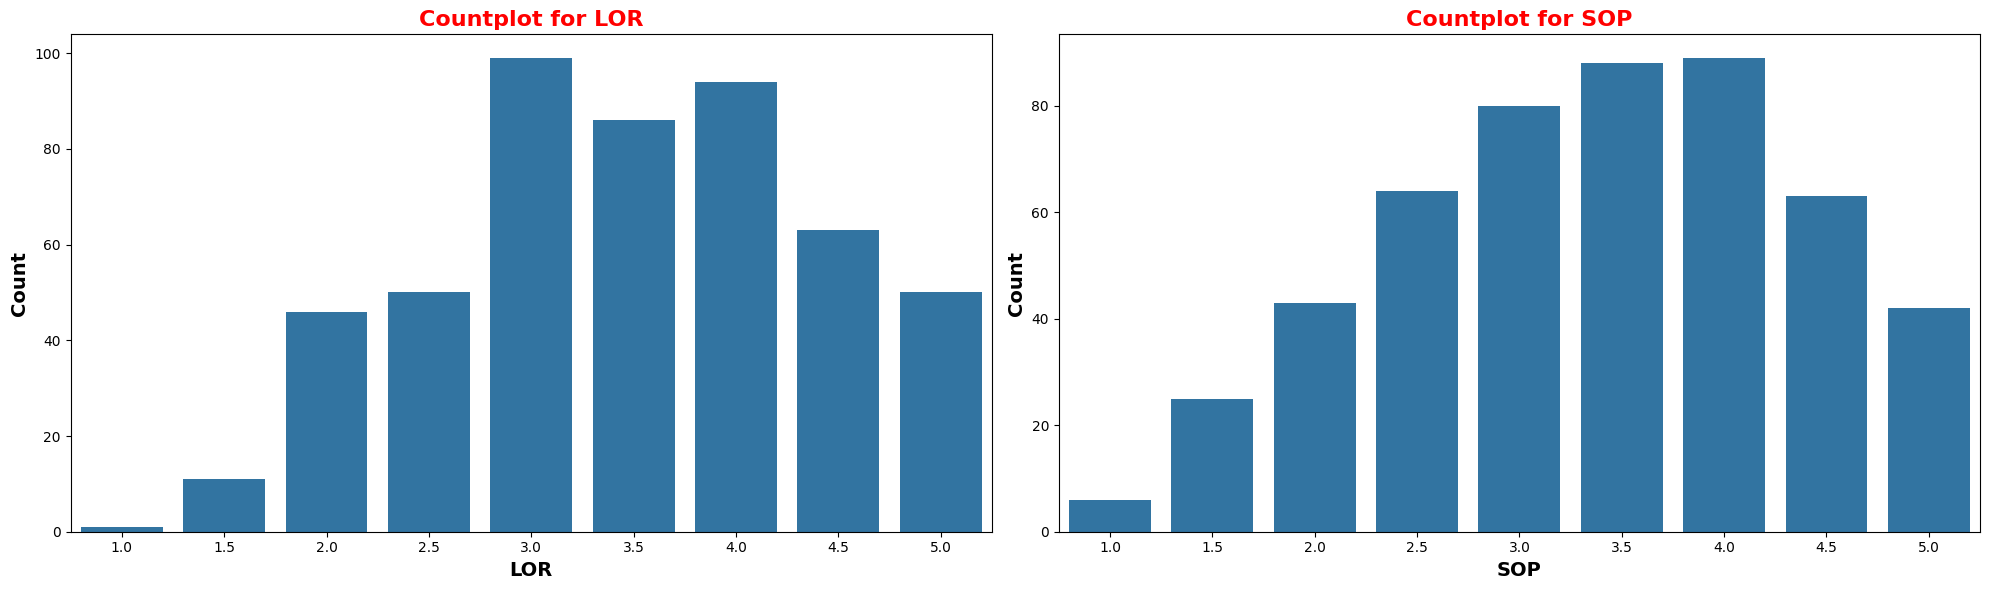

In [25]:
# Countplots for LOR and SOP
features = ['LOR', 'SOP']

fig, axes = plt.subplots(1, 2, figsize = (20, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.countplot(x = df[feature], ax = ax)
    ax.set_title(f'Countplot for {feature}', fontsize = 16, fontweight = 'bold', color = 'red')
    ax.set_xlabel(feature, fontsize = 14, fontweight = 'bold')
    ax.set_ylabel('Count', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

### **LOR and SOP ratings are concentrated in the mid-to-high range (3–4), indicating most applicants have reasonably strong recommendations and statements, with very few low-rated cases.**

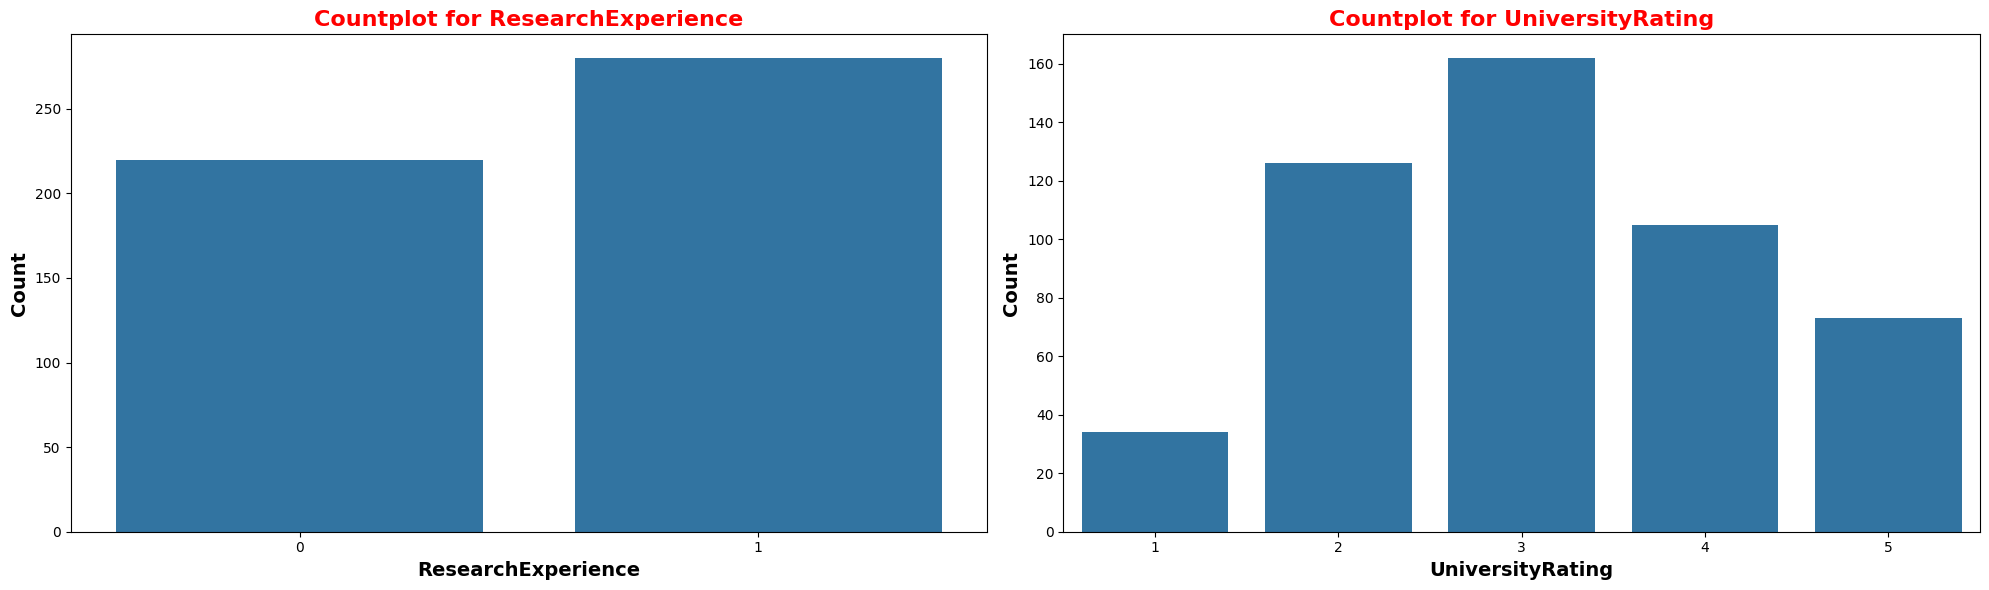

In [26]:
# Countplots for Research Experience and University Rating
features = ['ResearchExperience', 'UniversityRating']

fig, axes = plt.subplots(1, 2, figsize = (20, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.countplot(x = df[feature], ax = ax)
    ax.set_title(f'Countplot for {feature}', fontsize = 16, fontweight = 'bold', color = 'red')
    ax.set_xlabel(feature, fontsize = 14, fontweight = 'bold')
    ax.set_ylabel('Count', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

### **Most applicants have prior research experience, and university ratings are skewed toward mid-tier institutions (ratings 2–3), with fewer applicants from the lowest- and highest-rated universities.**

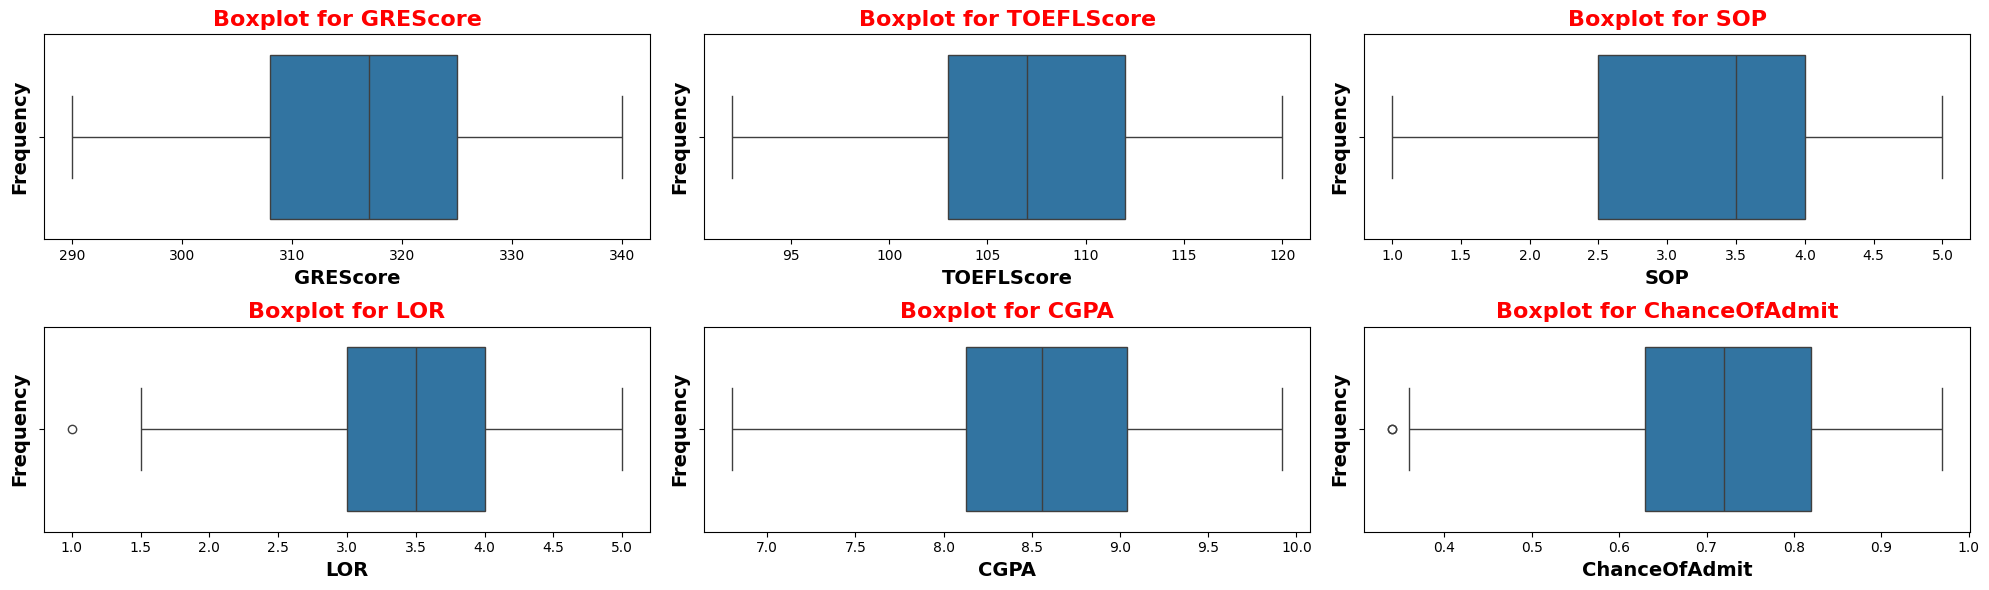

In [27]:
# Boxplots for all the features except University Rating and Research Experience

features = ['GREScore', 'TOEFLScore', 'SOP', 'LOR', 'CGPA', 'ChanceOfAdmit']

fig, axes = plt.subplots(2, 3, figsize = (20, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.boxplot(x = df[feature], ax = ax)
    ax.set_title(f'Boxplot for {feature}', fontsize = 16, fontweight = 'bold', color = 'red')
    ax.set_xlabel(feature, fontsize = 14, fontweight = 'bold')
    ax.set_ylabel('Frequency', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

### **The boxplots show that most variables have moderate spread with few mild outliers (notably in LOR and Chance of Admit), indicating generally well-behaved distributions without severe skewness or extreme anomalies.**

# **Part C2: Bivariate Analysis:**

In [28]:
df.head()

,GREScore,TOEFLScore,UniversityRating,SOP,LOR,CGPA,ResearchExperience,ChanceOfAdmit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


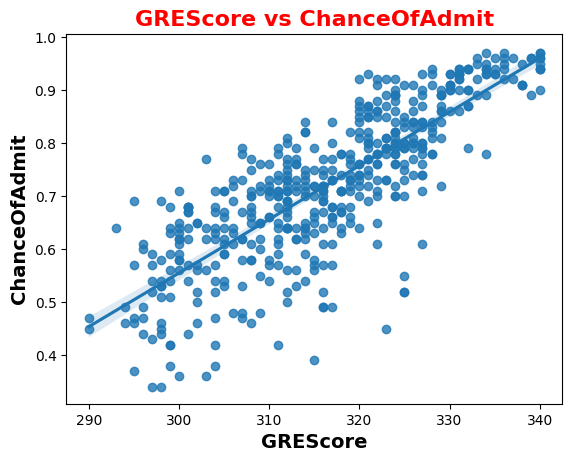

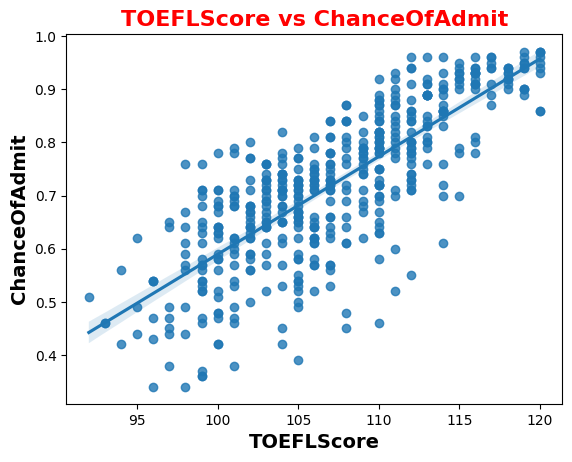

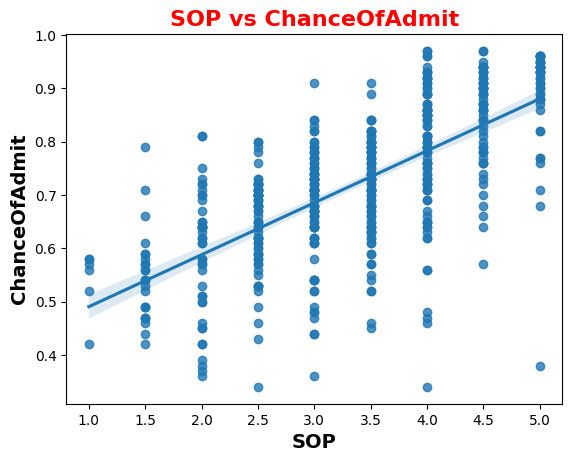

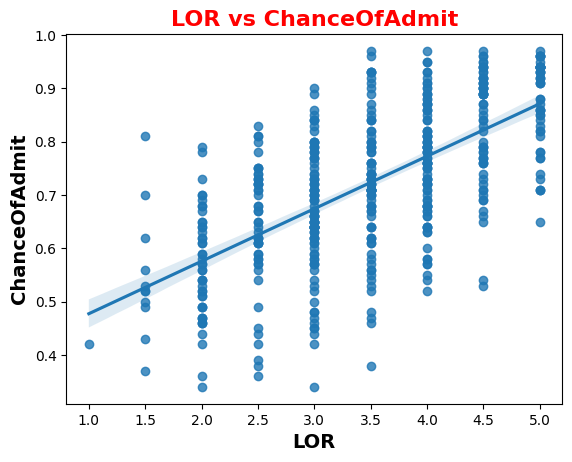

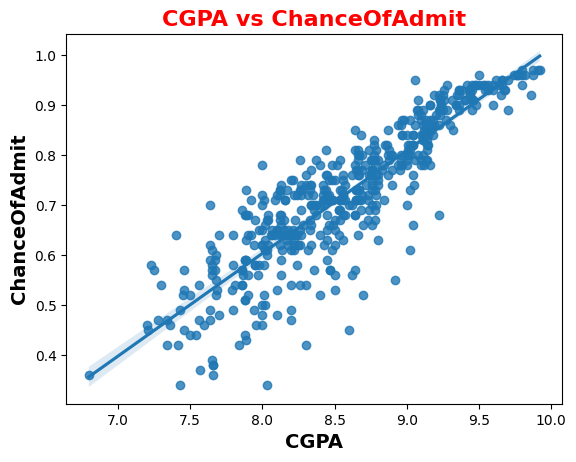

In [29]:
features = ['GREScore', 'TOEFLScore', 'SOP', 'LOR', 'CGPA']

for col in features:
    sns.regplot(x = df[col], y = df['ChanceOfAdmit'])
    plt.title(f'{col} vs ChanceOfAdmit', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('ChanceOfAdmit', fontsize = 14, fontweight = 'bold')
    plt.show()

**GREScore vs ChanceOfAdmit: GRE scores (290–340) display a strong positive linear trend with admission probability, where the fitted line rises steadily from ~0.45 at 290 to ~0.95 at 340, indicating GRE as a highly predictive factor.**

**TOEFLScore vs ChanceOfAdmit: TOEFL scores (95–120) show a solid positive linear relationship with admission chances, with the trend line climbing from ~0.45 at 95 to ~0.95 at 120 and relatively dense points along the upward slope.**

**SOP vs ChanceOfAdmit: Higher Statement of Purpose (SOP) ratings (1.0–5.0) show a moderate positive relationship with admission chances, with a fitted trend line rising from ~0.50 to ~0.85, though considerable scatter exists even at high SOP scores.**

**LOR vs ChanceOfAdmit: Stronger Letters of Recommendation (LOR) ratings (1.0–5.0) are associated with notably higher admission probabilities, following a clear upward trend from ~0.50 to ~0.88, with increasing density of high-chance points at higher LOR values.**

**CGPA vs ChanceOfAdmit: CGPA (7.0–10.0) exhibits one of the strongest linear positive correlations with admission chances, with the trend line steeply increasing from ~0.40 at 7.0 to nearly 1.0 at 10.0 and tight clustering along the line.**

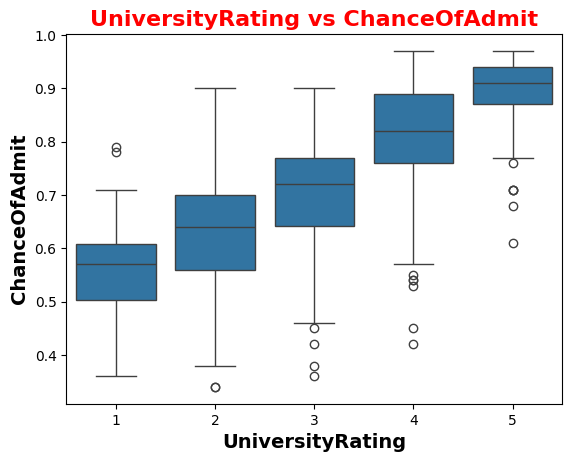

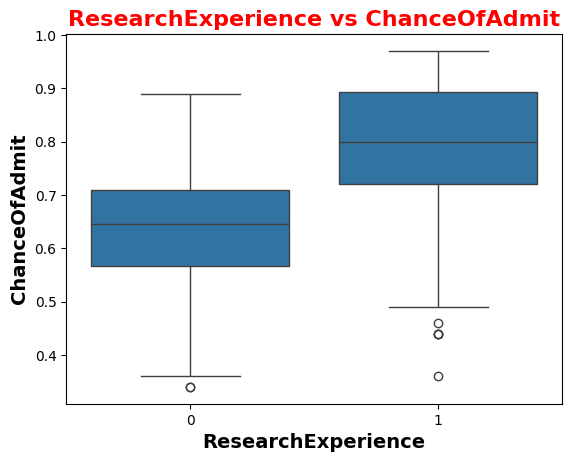

In [30]:
features = ['UniversityRating', 'ResearchExperience']

for col in features:
    sns.boxplot(x = df[col], y = df['ChanceOfAdmit'])
    plt.title(f'{col} vs ChanceOfAdmit', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('ChanceOfAdmit', fontsize = 14, fontweight = 'bold')
    plt.show()

**UniversityRating vs ChanceOfAdmit: Admission chances show a clear upward trend with higher university ratings (1 to 5), with medians rising from ~0.58 at rating 1 to ~0.88 at rating 5 and reduced variability at the top tiers.**

**ResearchExperience vs ChanceOfAdmit: Applicants with research experience (1) have markedly higher median admission chances (~0.80) and a tighter, more favorable distribution compared to those without (median ~0.65).**

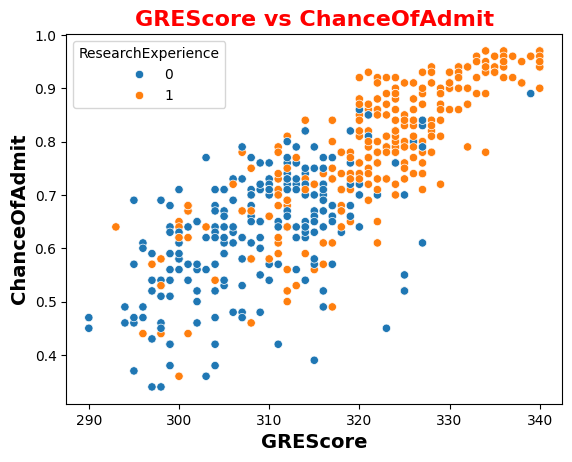

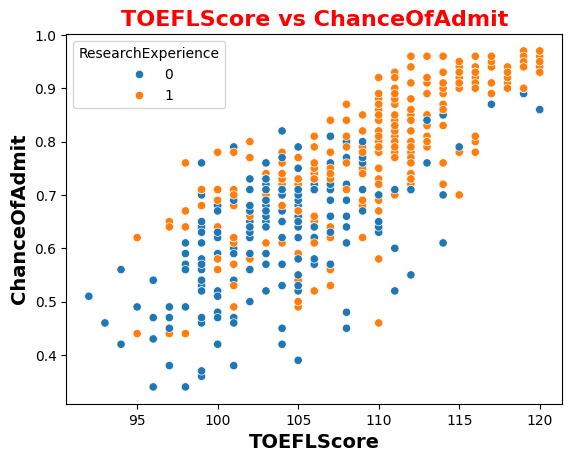

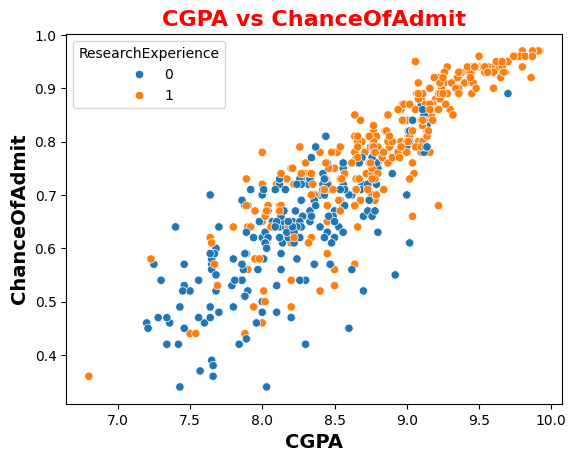

In [31]:
features = ['GREScore', 'TOEFLScore', 'CGPA']

for col in features:
    sns.scatterplot(x = col, y = 'ChanceOfAdmit', hue = 'ResearchExperience', data = df)
    plt.title(f'{col} vs ChanceOfAdmit', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('ChanceOfAdmit', fontsize = 14, fontweight = 'bold')
    plt.show()

**GREScore vs ChanceOfAdmit (by ResearchExperience): GRE scores exhibit a strong positive linear relationship with admission probability, with research-experienced applicants tending to cluster toward higher chances for any given GRE score compared to those without.**

**TOEFLScore vs ChanceOfAdmit (by ResearchExperience): Higher TOEFL scores (95–120) are strongly associated with increased admission chances, and applicants with research experience generally achieve higher probabilities than those without at similar TOEFL levels.**

**CGPA vs Chance of Admit (by Research Experience): CGPA shows a strong positive relationship with admission chances, and applicants with research experience consistently have higher probabilities than those without at the same CGPA.**

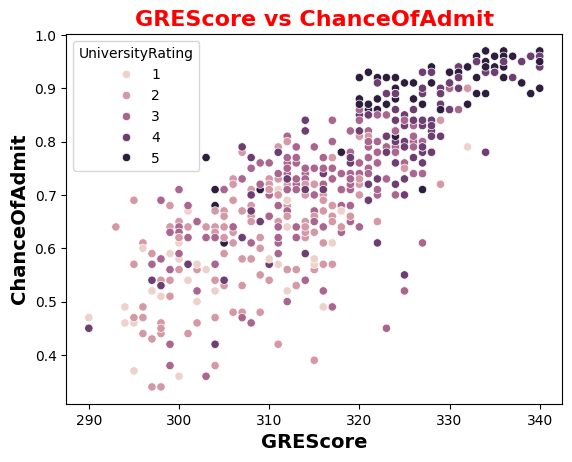

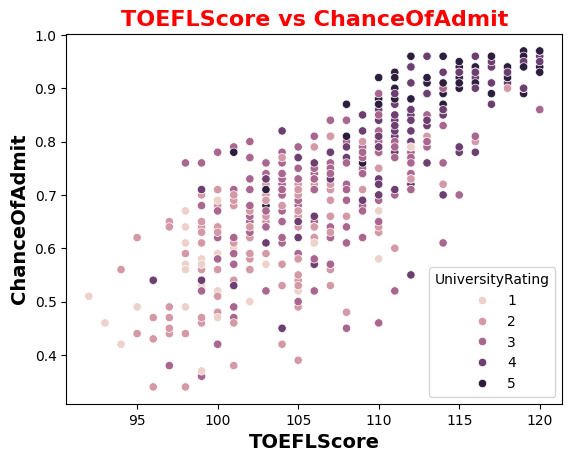

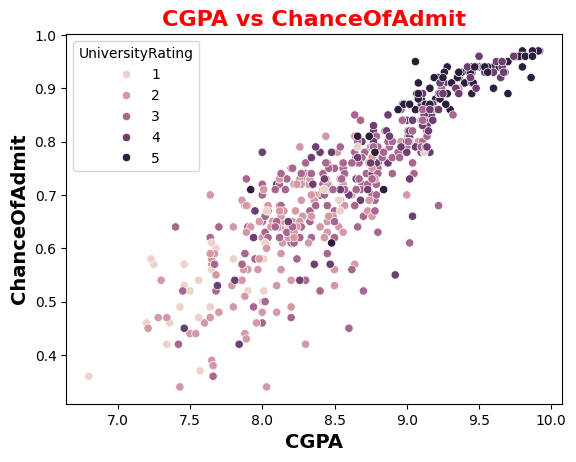

In [32]:
features = ['GREScore', 'TOEFLScore', 'CGPA']

for col in features:
    sns.scatterplot(x = col, y = 'ChanceOfAdmit', hue = 'UniversityRating', data = df)
    plt.title(f'{col} vs ChanceOfAdmit', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('ChanceOfAdmit', fontsize = 14, fontweight = 'bold')
    plt.show()

**GRE Score vs Chance of Admit (by University Rating): Chance of admission increases steadily with higher GRE scores, with stronger clustering at higher probabilities for candidates from higher-rated universities.**

**TOEFL Score vs Chance of Admit (by University Rating): Higher TOEFL scores correlate with higher admission chances, with stronger university ratings amplifying this effect.**

**CGPA vs Chance of Admit (by University Rating): CGPA shows a strong, near-linear positive relationship with admission probability, making it one of the most influential predictors.**

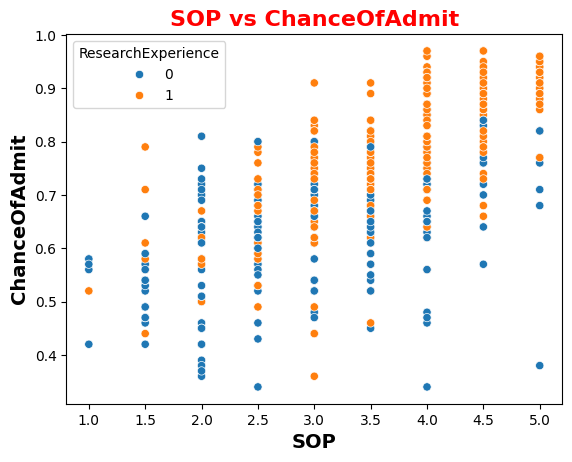

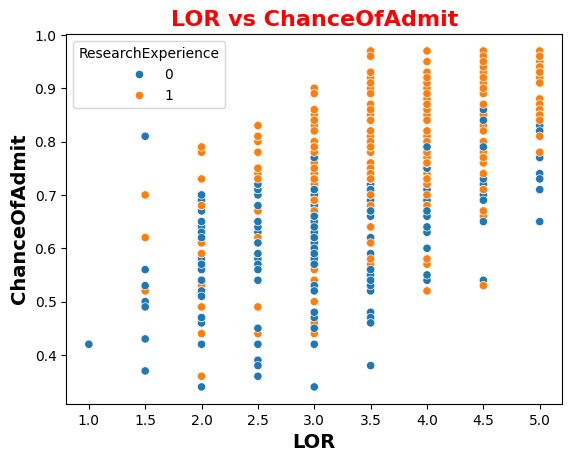

In [33]:
features = ['SOP', 'LOR']

for col in features:
    sns.scatterplot(x = col, y = 'ChanceOfAdmit', hue = 'ResearchExperience', data = df)
    plt.title(f'{col} vs ChanceOfAdmit', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('ChanceOfAdmit', fontsize = 14, fontweight = 'bold')
    plt.show()

**LOR vs Chance of Admit (by Research Experience): Applicants with research experience have a consistently higher chance of admission than those without, especially at mid-to-high LOR scores.**

**SOP vs Chance of Admit (by Research Experience): Research experience positively shifts admission chances upward across all SOP scores, indicating its strong complementary role.**

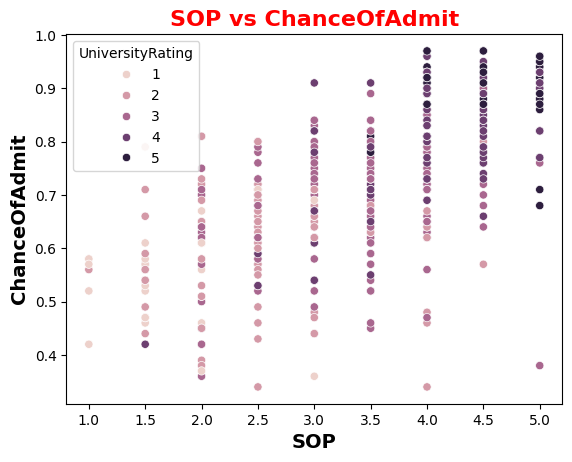

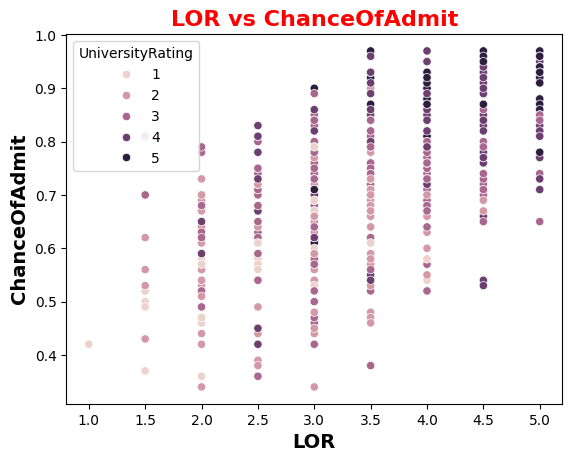

In [34]:
features = ['SOP', 'LOR']

for col in features:
    sns.scatterplot(x = col, y = 'ChanceOfAdmit', hue = 'UniversityRating', data = df)
    plt.title(f'{col} vs ChanceOfAdmit', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('ChanceOfAdmit', fontsize = 14, fontweight = 'bold')
    plt.show()

**LOR vs Chance of Admit (by University Rating): Higher LOR scores are associated with higher admission chances, with top-rated universities consistently showing better outcomes at the same LOR level.**

**SOP vs Chance of Admit (by University Rating): Admission probability increases with SOP strength, and candidates from higher-rated universities tend to have an edge across SOP levels.**

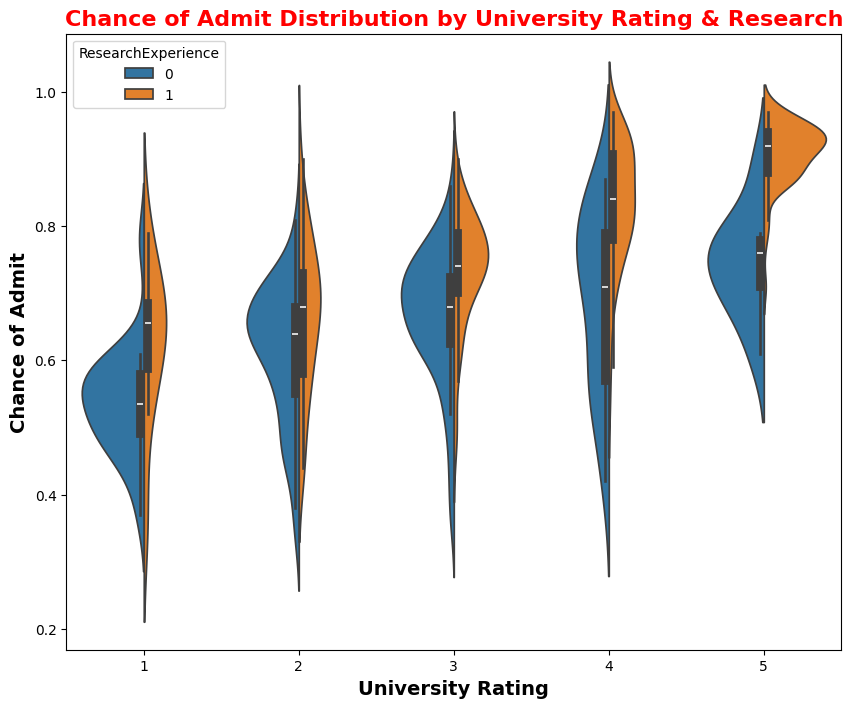

In [35]:
plt.figure(figsize = (10, 8))
sns.violinplot(x = 'UniversityRating', y = 'ChanceOfAdmit', hue = 'ResearchExperience', data = df, split = True)
plt.title('Chance of Admit Distribution by University Rating & Research', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel('University Rating', fontsize = 14, fontweight = 'bold')
plt.ylabel('Chance of Admit', fontsize = 14, fontweight = 'bold')
plt.show()

### **The violin plots demonstrate that admission chance distributions shift rightward and become more positively skewed toward higher probabilities with increasing university ratings (1–5), with research experience consistently boosting the density in the upper tail for each rating.**

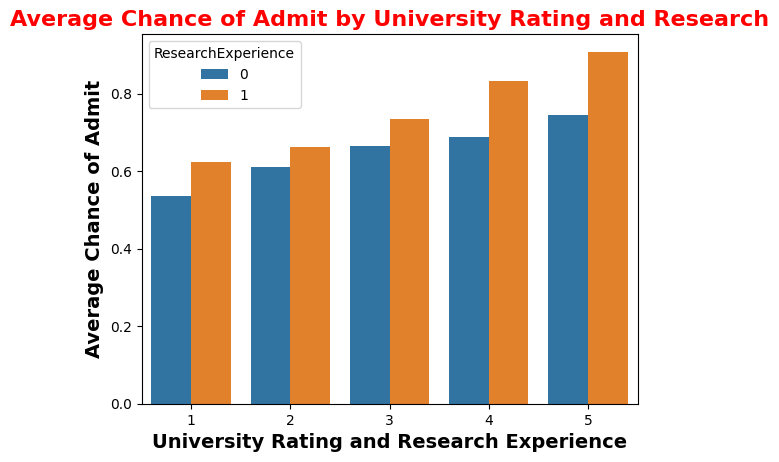

In [36]:
grouped = df.groupby(['UniversityRating', 'ResearchExperience'])['ChanceOfAdmit'].mean().reset_index()

sns.barplot(x = 'UniversityRating', y = 'ChanceOfAdmit', hue = 'ResearchExperience', data = grouped)
plt.title('Average Chance of Admit by University Rating and Research', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel('University Rating and Research Experience', fontsize = 14, fontweight = 'bold')
plt.ylabel('Average Chance of Admit', fontsize = 14, fontweight = 'bold')
plt.show()

### **The bar chart illustrates that average admission chances rise with higher university ratings (starting from 1 to 5), with applicants having research experience consistently showing slightly higher probabilities than those without.**

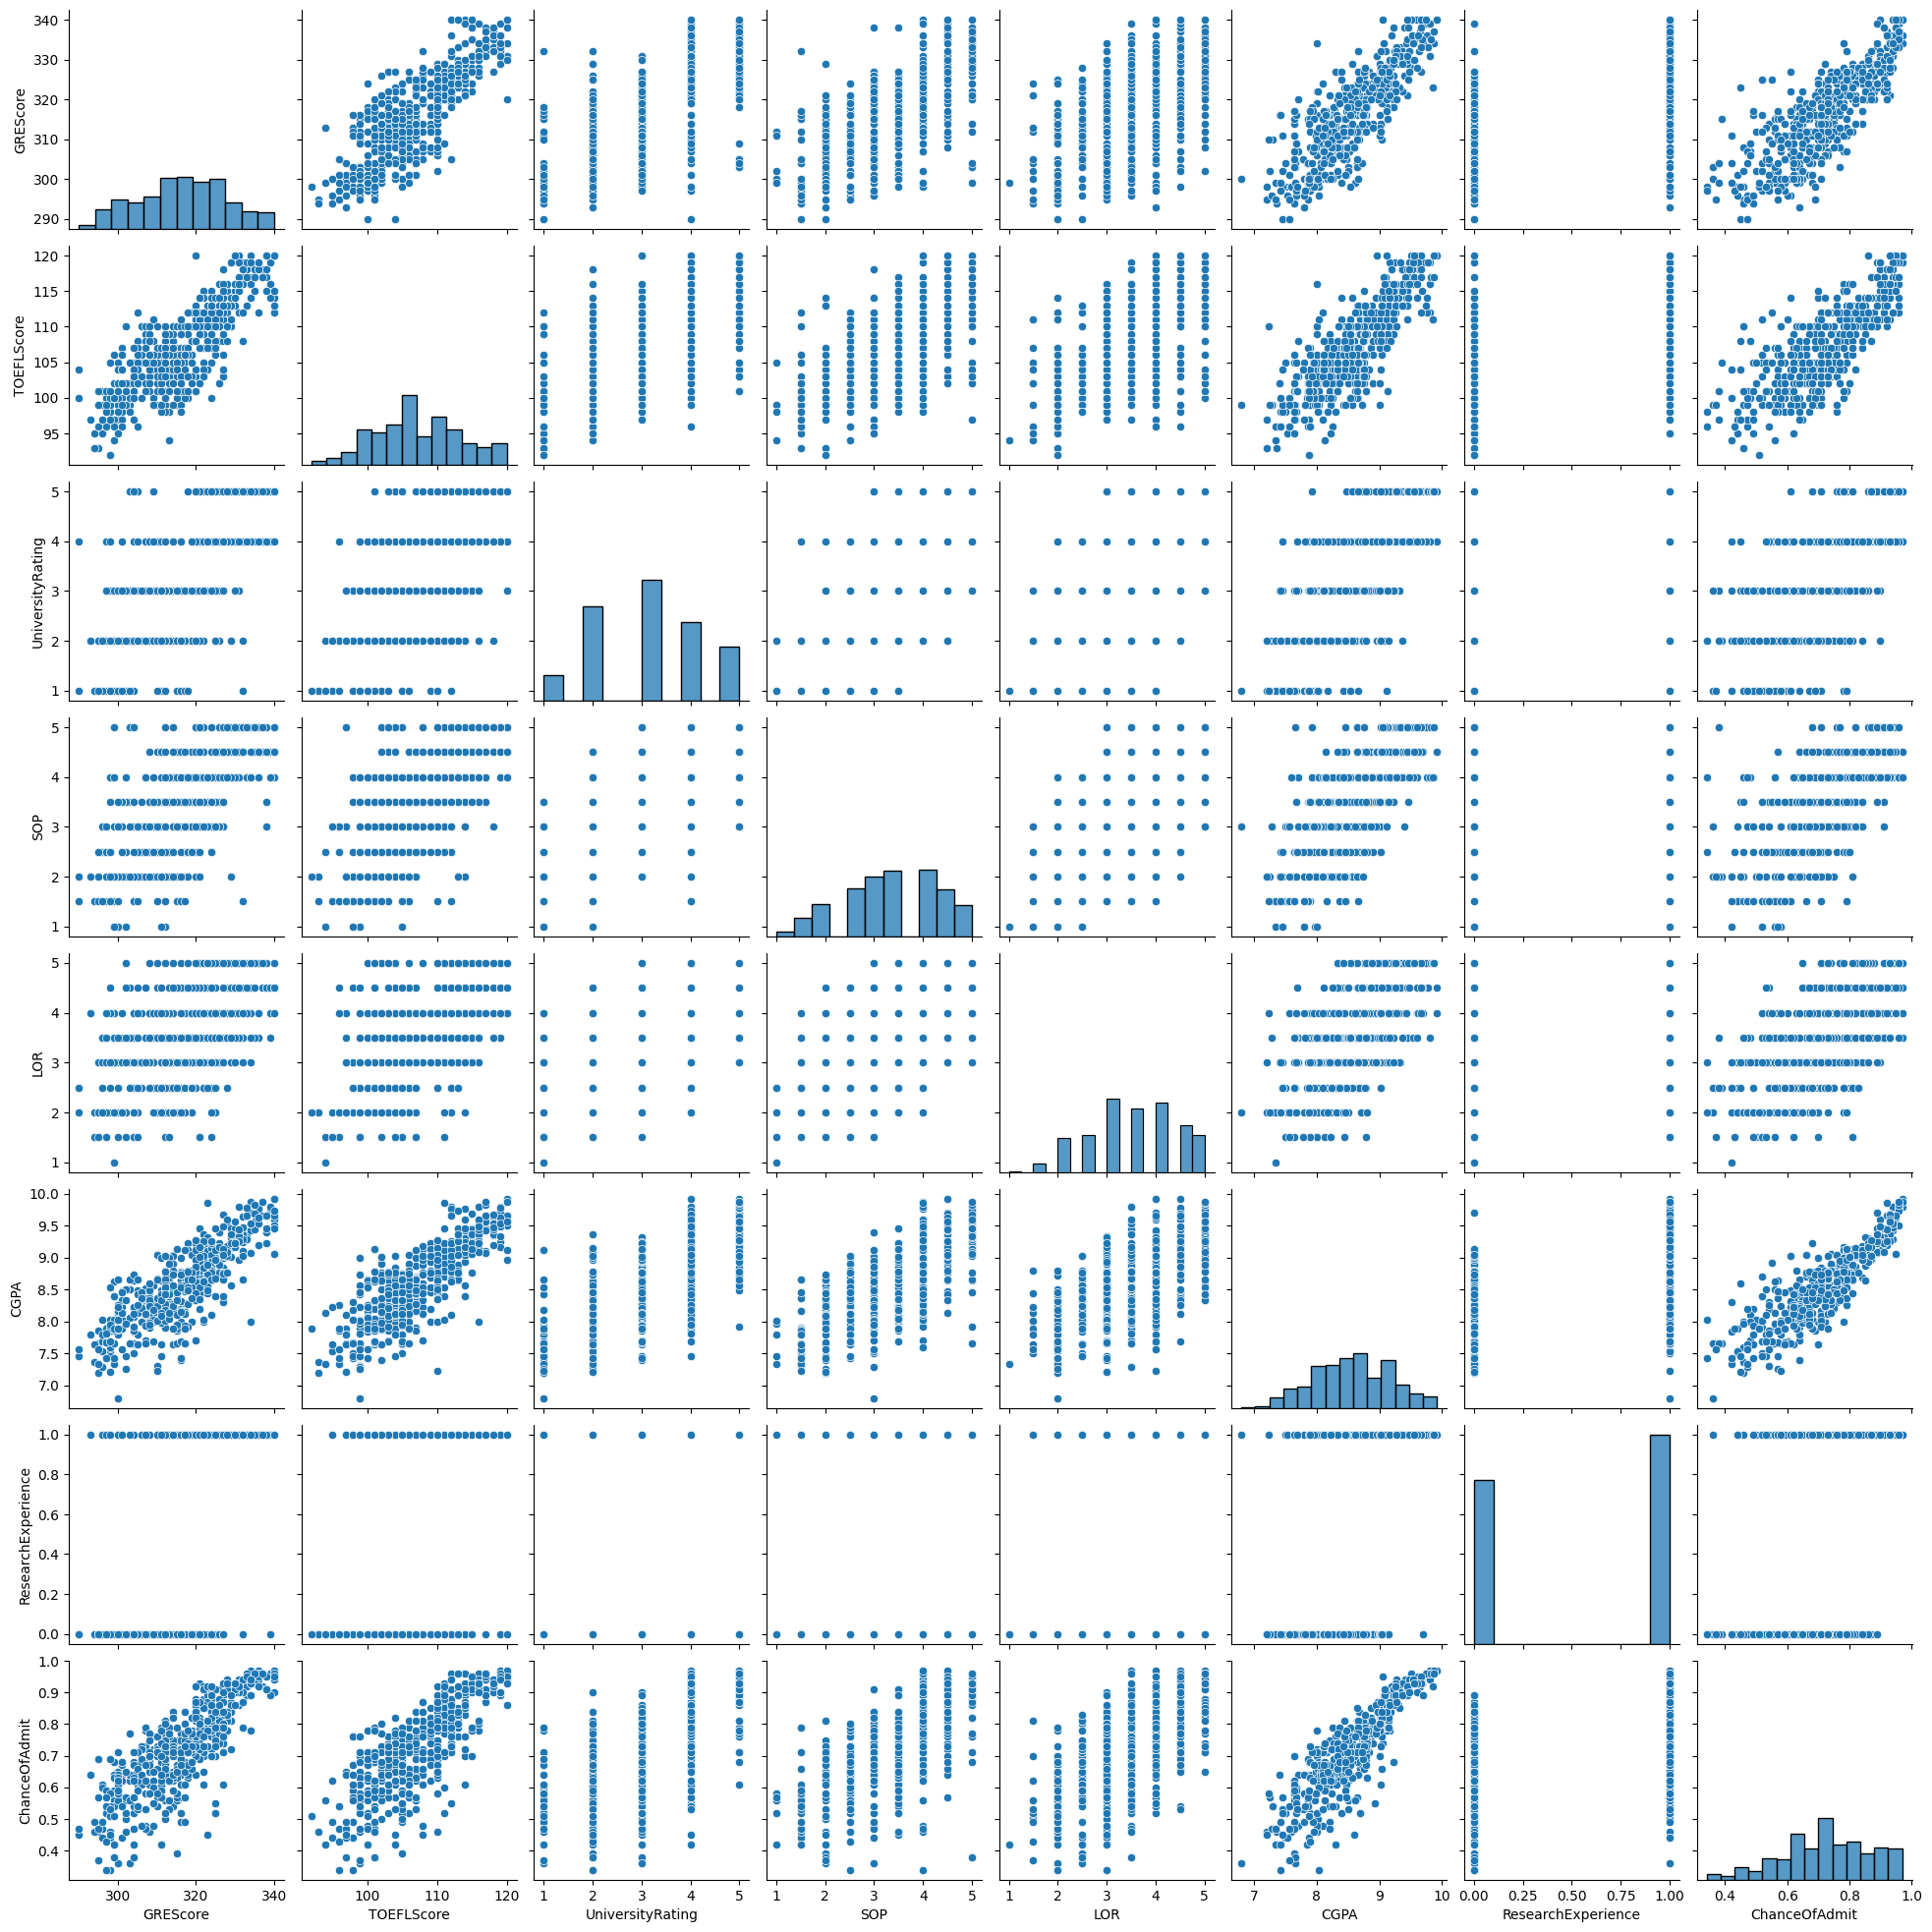

In [37]:
# Pairplot
sns.pairplot(df)
plt.show()

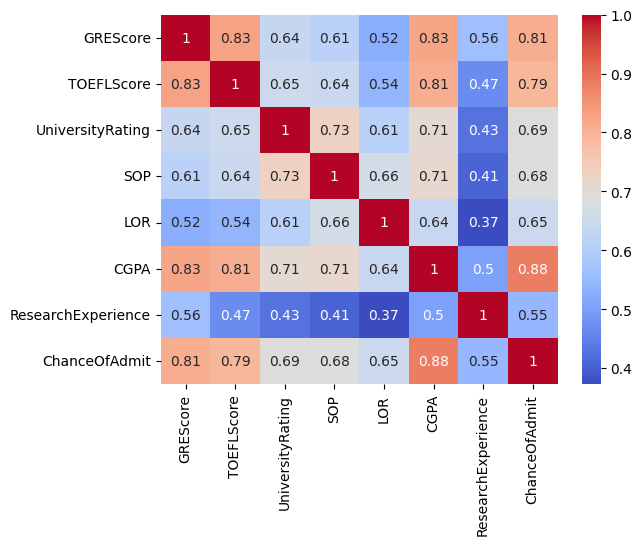

In [38]:
# Heatmap for correlation
sns.heatmap(df.corr(), cmap= 'coolwarm', annot = True)
plt.show()

### **The correlation heatmap shows that CGPA has the strongest positive relationship with Chance of Admit, followed by GRE and TOEFL scores, while moderate inter-correlations among predictors suggest some multicollinearity.**

# **Outlier Treatment:**

# **Detect Outliers using IQR:**

In [39]:
df.head()

,GREScore,TOEFLScore,UniversityRating,SOP,LOR,CGPA,ResearchExperience,ChanceOfAdmit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [40]:
df[(df['ChanceOfAdmit'] < 0) | (df['ChanceOfAdmit'] > 1)]

,GREScore,TOEFLScore,UniversityRating,SOP,LOR,CGPA,ResearchExperience,ChanceOfAdmit


In [41]:
features = ['GREScore', 'TOEFLScore', 'SOP', 'LOR', 'CGPA']

for col in features:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
  print(f"{col}: {outlier_count} outliers")

GREScore: 0 outliers
TOEFLScore: 0 outliers
SOP: 0 outliers
LOR: 1 outliers
CGPA: 0 outliers


## **One outlier was detected in LOR using the IQR method. Since LOR is an ordinal variable with a limited range, the value was retained and no treatment was applied.**

### If a value cannot exist in the real world → remove it. If it can exist but is rare → keep or cap it.

# **Linear Regression Model:**

**Note:** Encoding is required only when variables are categorical text. GREScore, TOEFLScore and CGPA are continuous. SOP, LOR and UniversityRating are ordinal (range of 1-5). ResearchExperience is binary (0 or 1). ChanceOfAdmit is the target variable and is continuous.

In [42]:
# Data Preparation for Modelling
X = df.drop('ChanceOfAdmit', axis=1)
y = df['ChanceOfAdmit']

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns, index = X_test.index)

# Model fit
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          ChanceOfAdmit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Sun, 25 Jan 2026   Prob (F-statistic):          3.41e-142
Time:                        07:44:45   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7242      0

# **Testing the Assumptions of the Linear Regression Model:**

In [43]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['Features'] = X_train_scaled.columns
vif['VIF'] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
5,CGPA,4.65
0,GREScore,4.49
1,TOEFLScore,3.66
3,SOP,2.79
2,UniversityRating,2.57
4,LOR,1.98
6,ResearchExperience,1.52


## **Multicollinearity was assessed using the Variance Inflation Factor (VIF). All predictor variables have VIF values below the threshold of 5, indicating no significant multicollinearity among the independent variables. Hence, all features were retained for model building.**

Mean of residuals: -4.056477376224166e-16


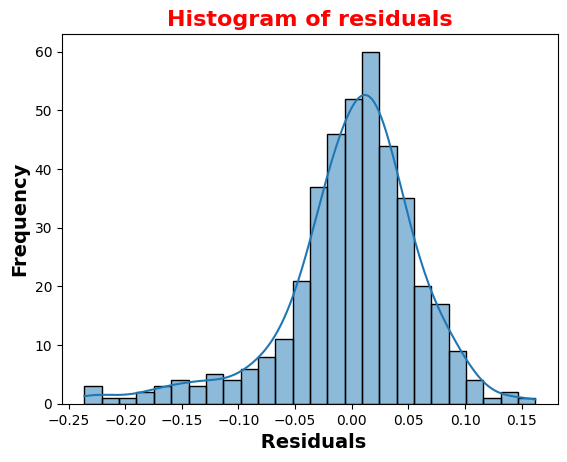

In [44]:
# Check if the mean of residuals is nearly zero
X_train_sm = sm.add_constant(X_train_scaled)
sm_model = sm.OLS(y_train, X_train_sm).fit()
y_hat = sm_model.predict(X_train_sm)
residuals = y_train - y_hat
print("Mean of residuals:", residuals.mean())

import seaborn as sns
sns.histplot(residuals, kde = True)
plt.title("Histogram of residuals", fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel(" Residuals", fontsize = 14, fontweight = 'bold')
plt.ylabel("Frequency", fontsize = 14, fontweight = 'bold')
plt.show()

## **The mean of the residuals is approximately zero (-4.056477376224166e-16), the tiny value is due to floating-point precision, confirming that the model is unbiased and satisfies the zero-mean assumption.**

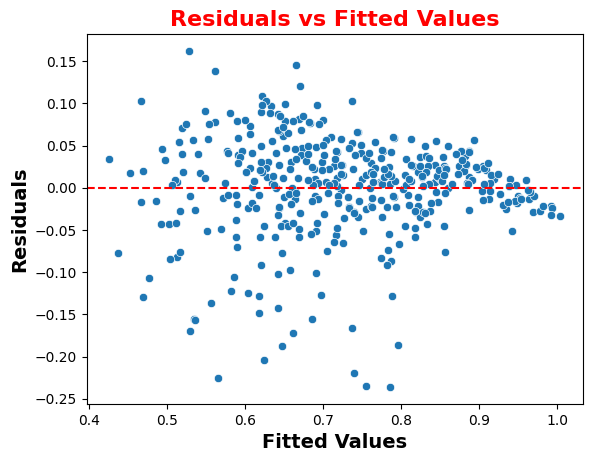

In [45]:
# Linearity of variables
fitted_vals = sm_model.fittedvalues
residuals = sm_model.resid

import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values", fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel("Fitted Values", fontsize = 14, fontweight = 'bold')
plt.ylabel("Residuals", fontsize = 14, fontweight = 'bold')
plt.show()

### **Residuals are randomly scattered. No systematic curve or pattern. Linearity assumption is satisfied.**

### **Variance is fairly constant. Slight tightening of spread at higher fitted values, but not severe. Homoscedasticity is reasonably satisfied. In real-world datasets, perfect homoscedasticity is rare. This plot is absolutely acceptable.**

### **The residuals versus fitted values plot shows a random scatter around zero with no visible pattern, confirming the linearity assumption. The spread of residuals remains fairly constant across fitted values, indicating that the homoscedasticity assumption is reasonably satisfied.**

In [46]:
from scipy import stats
res = stats.shapiro(residuals)

print("W statistic:", res.statistic)
print("p-value:", res.pvalue)

W statistic: 0.9291008662710222
p-value: 7.73490673060497e-13


## **p-value > 0.05 → Fail to reject H₀ → residuals are approximately normal**

## **p-value ≤ 0.05 → Reject H₀ → residuals deviate from normality**

In [47]:
# Goldfeld-Quandt test for heteroskedasticity using statsmodels
from statsmodels.compat import lzip
import statsmodels.stats.api as sm

name = ['F statistic', 'p-value']
test = sm.het_goldfeldquandt(y_train, X_train_sm)
print(lzip(name, test),"\n")

f_stat, p_value, ordering = test[:3]   # first three returned values
print(f"Goldfeld-Quandt test:")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print(f"  Alternative : variance is {ordering}")

[('F statistic', np.float64(0.9506884043302335)), ('p-value', np.float64(0.6367845922442998))] 

Goldfeld-Quandt test:
  F-statistic : 0.9507
  p-value     : 0.6368
  Alternative : variance is increasing


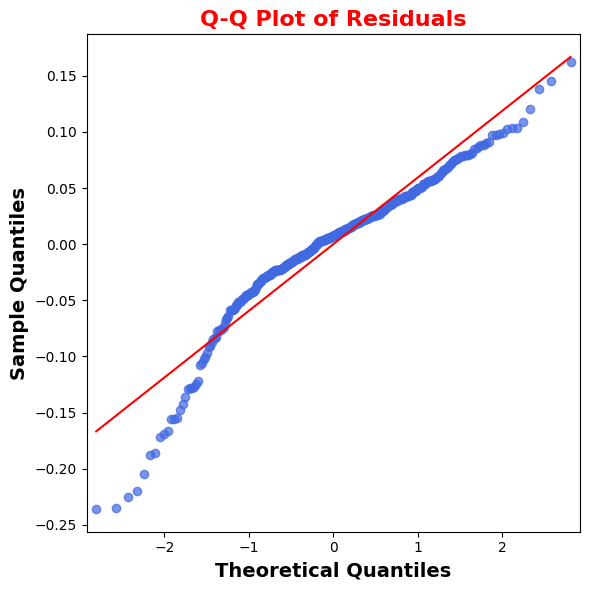

In [48]:
# Normality of residuals (almost bell-shaped curve in residuals distribution, points in QQ plot are almost all on the line)
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(111)
ax = sm.qqplot(residuals, line = 's', ax = ax, markerfacecolor = 'royalblue', markeredgecolor = 'royalblue', alpha = 0.7)
plt.title("Q-Q Plot of Residuals", fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel("Theoretical Quantiles", fontsize = 14, fontweight = 'bold')
plt.ylabel("Sample Quantiles", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [49]:
# Model performance evaluation
# Metrics checked - MAE, RMSE, R2, Adj R2
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

n = len(y_train)
p = X_train_scaled.shape[1]

mae = mean_absolute_error(y_train, y_hat)
rmse = np.sqrt(mean_squared_error(y_train, y_hat))
r2 = r2_score(y_train, y_hat)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Model Performance Metrics:")
print(f"MAE          : {mae:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"R²           : {r2:.4f}")
print(f"Adjusted R²  : {adj_r2:.4f}")

Model Performance Metrics:
MAE          : 0.0425
RMSE         : 0.0594
R²           : 0.8211
Adjusted R²  : 0.8179


# **Ridge Linear Regression:**

### **After validating linear regression assumptions and evaluating baseline model performance, Ridge and Lasso regression were applied to address multicollinearity and assess coefficient stability and feature importance.**

In [50]:
# Build the model
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 1.0)   # you can mention alpha chosen by trial
ridge.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

# Evaluations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train metrics
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

# Test metrics
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print("Ridge Regression Performance:")
print(f"Train RMSE: {rmse_train_ridge:.4f}, R²: {r2_train_ridge:.4f}")
print(f"Test  RMSE: {rmse_test_ridge:.4f}, R²: {r2_test_ridge:.4f}")

# Ridge Coefficients
ridge_coeff = pd.DataFrame({"Feature": X_train.columns, "Coefficient": ridge.coef_})
ridge_coeff

Ridge Regression Performance:
Train RMSE: 0.0594, R²: 0.8211
Test  RMSE: 0.0609, R²: 0.8188


,Feature,Coefficient
0,GREScore,0.026789
1,TOEFLScore,0.018355
2,UniversityRating,0.003046
3,SOP,0.001937
4,LOR,0.015893
5,CGPA,0.067011
6,ResearchExperience,0.011949


# **Lasso Linear Regression:**

In [51]:
# Build the model
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 1.0)   # alpha chosen by trial
lasso.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

# Evaluations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train metrics
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

# Test metrics
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso Regression Performance:")
print(f"Train RMSE: {rmse_train_lasso:.4f}, R²: {r2_train_lasso:.4f}")
print(f"Test  RMSE: {rmse_test_lasso:.4f}, R²: {r2_test_lasso:.4f}")

# Ridge Coefficients
lasso_coeff = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lasso.coef_})
lasso_coeff

Lasso Regression Performance:
Train RMSE: 0.1404, R²: 0.0000
Test  RMSE: 0.1435, R²: -0.0072


,Feature,Coefficient
0,GREScore,0.0
1,TOEFLScore,0.0
2,UniversityRating,0.0
3,SOP,0.0
4,LOR,0.0
5,CGPA,0.0
6,ResearchExperience,0.0


In [52]:
# Build the model
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 0.001)
lasso.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

# Evaluations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train metrics
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

# Test metrics
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso Regression Performance:")
print(f"Train RMSE: {rmse_train_lasso:.4f}, R²: {r2_train_lasso:.4f}")
print(f"Test  RMSE: {rmse_test_lasso:.4f}, R²: {r2_test_lasso:.4f}")

# Ridge Coefficients
lasso_coeff = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lasso.coef_})
lasso_coeff

Lasso Regression Performance:
Train RMSE: 0.0594, R²: 0.8210
Test  RMSE: 0.0608, R²: 0.8192


,Feature,Coefficient
0,GREScore,0.026612
1,TOEFLScore,0.017919
2,UniversityRating,0.002746
3,SOP,0.001592
4,LOR,0.015392
5,CGPA,0.067734
6,ResearchExperience,0.011360


### **Lasso regression initially shrank all coefficients to zero due to a relatively high regularization strength. This indicates that, at that penalty level, none of the predictors provided sufficient marginal contribution. After tuning the regularization parameter, Lasso retained the most influential features while discarding weaker ones, demonstrating its capability for automatic feature selection.**

In [53]:
# Build the model
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas = [0.0001, 0.001, 0.01, 0.1], cv = 5, max_iter = 1000)
lasso_cv.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso_cv.predict(X_train_scaled)
y_test_pred_lasso = lasso_cv.predict(X_test_scaled)

print("Best alpha:", lasso_cv.alpha_)
print("Non-zero coefficients:", (lasso_cv.coef_ != 0).sum())

# Evaluations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train metrics
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

# Test metrics
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso Regression Performance:")
print(f"Train RMSE: {rmse_train_lasso:.4f}, R²: {r2_train_lasso:.4f}")
print(f"Test  RMSE: {rmse_test_lasso:.4f}, R²: {r2_test_lasso:.4f}")

# Ridge Coefficients
lasso_coeff = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lasso.coef_})
lasso_coeff

Best alpha: 0.001
Non-zero coefficients: 7
Lasso Regression Performance:
Train RMSE: 0.0594, R²: 0.8210
Test  RMSE: 0.0608, R²: 0.8192


,Feature,Coefficient
0,GREScore,0.026612
1,TOEFLScore,0.017919
2,UniversityRating,0.002746
3,SOP,0.001592
4,LOR,0.015392
5,CGPA,0.067734
6,ResearchExperience,0.011360


### **max_iter controls the convergence of the Lasso optimization algorithm. Since the dataset is small, features are scaled, and no convergence warnings are observed, the default value of 1000 iterations is sufficient. Higher values like 5000 are often used as a precaution for more complex or high-dimensional datasets.**

In [54]:
# Build the model
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3], cv = 5, max_iter = 1000)
lasso_cv.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso_cv.predict(X_train_scaled)
y_test_pred_lasso = lasso_cv.predict(X_test_scaled)

print("Best alpha:", lasso_cv.alpha_)
print("Non-zero coefficients:", (lasso_cv.coef_ != 0).sum())

# Evaluations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train metrics
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

# Test metrics
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso Regression Performance:")
print(f"Train RMSE: {rmse_train_lasso:.4f}, R²: {r2_train_lasso:.4f}")
print(f"Test  RMSE: {rmse_test_lasso:.4f}, R²: {r2_test_lasso:.4f}")

# Ridge Coefficients
lasso_coeff = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lasso.coef_})
lasso_coeff

Best alpha: 0.001
Non-zero coefficients: 7
Lasso Regression Performance:
Train RMSE: 0.0594, R²: 0.8210
Test  RMSE: 0.0608, R²: 0.8192


,Feature,Coefficient
0,GREScore,0.026612
1,TOEFLScore,0.017919
2,UniversityRating,0.002746
3,SOP,0.001592
4,LOR,0.015392
5,CGPA,0.067734
6,ResearchExperience,0.011360


### **Lasso regression was attempted with multiple finely tuned alpha values. However, due to strong multicollinearity among predictors and the small dataset size, Lasso resulted in all coefficients shrinking to zero, indicating severe underfitting. Hence, Lasso is not suitable for this problem. Ridge regression and Ordinary Least Squares provide better predictive performance and stability.**

# **Significance of Predictor Variables:**
**CGPA** shows the highest positive association with Chance of Admit, suggesting that consistent academic performance is the most critical factor influencing admission decisions.

**GRE Score and TOEFL Score** also exhibit strong positive relationships with the target variable, reinforcing the importance of standardized test performance in evaluating applicants.

**University Rating, SOP, and LOR** demonstrate moderate positive influence, indicating that qualitative assessments and institutional reputation contribute meaningfully, though to a lesser extent than academic scores.

**Research Experience** has a positive but comparatively weaker effect, implying that while research exposure improves admission chances, it acts more as a supporting factor rather than a primary determinant.

# **Actionable Insights & Recommendations:**
**Data Enhancement:** Model performance can be improved by adding contextual variables such as undergraduate institution ranking, field of study, work/internship experience, and research output, which are not captured in the current dataset.

**Real-World Use:** The model is best used as a decision-support tool for preliminary screening and applicant self-assessment, benefiting from the interpretability of linear and regularized regression models.

**Business Value:** A data-driven admission scoring system can reduce manual screening effort, ensure consistent evaluation, and improve candidate prioritization and admission yield.

**Overall Recommendation:** With richer features and periodic retraining, the model can scale into a transparent and reliable analytics tool for supporting graduate admissions decisions.